In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("consolidated_traffic_data.csv")

print(df.head())


      duration   total_fiat   total_biat  min_fiat  min_biat     max_fiat  \
0  119994459.0  119994459.0  119970125.0       0.0       0.0    1399330.0   
1  143704195.0  143704195.0   42106019.0       0.0       0.0  101572528.0   
2  119994980.0  119994980.0  119966891.0       7.0       0.0     819852.0   
3  119292282.0  119292282.0  119260024.0       3.0       0.0     912990.0   
4  119772966.0  119772917.0  119772939.0       4.0       0.0    2894671.0   

    max_biat     mean_fiat    mean_biat  flowPktsPerSecond  ...  \
0  1211310.0   2348.136257   513.267526        2373.792943  ...   
1   854818.0   6986.105737   636.898837         603.204381  ...   
2   819602.0  10201.919742  2341.411304         525.030297  ...   
3   866900.0  11947.148923  3354.712349         381.726288  ...   
4  2923147.0  18210.873803  3644.280989         329.331412  ...   

     std_flowiat   min_active  mean_active   max_active    std_active  \
0    9107.759178    1753114.0   11300000.0   39438693.0  1.60

In [3]:
#Dataset / Feature Compatibility Check

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nTarget classes:")
print(df["traffic_type"].nunique())
print(df["traffic_type"].value_counts())

Number of rows: 59706
Number of columns: 24

Column names:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle', 'traffic_type']

Missing values:
0

Target classes:
14
traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64


In [5]:
#Separate X and Y

In [6]:
X = df.drop("traffic_type", axis=1)
y = df["traffic_type"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (59706, 23)
Target: (59706,)


In [7]:
#Target Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['BROWSING' 'CHAT' 'FT' 'MAIL' 'P2P' 'STREAMING' 'VOIP' 'VPN-BROWSING'
 'VPN-CHAT' 'VPN-FT' 'VPN-MAIL' 'VPN-P2P' 'VPN-STREAMING' 'VPN-VOIP']


In [9]:
#Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (47764, 23)
Testing data: (11942, 23)


In [11]:
#XGBoost Model Build

In [12]:
from xgboost import XGBClassifier

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [14]:
#Model Accuracy

In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.8627533076536593


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

     BROWSING       0.88      0.89      0.89      2000
         CHAT       0.81      0.79      0.80       501
           FT       0.91      0.70      0.79       795
         MAIL       0.88      0.73      0.80       273
          P2P       0.91      0.98      0.94       800
    STREAMING       0.91      0.71      0.80       257
         VOIP       0.99      0.95      0.97      1297
 VPN-BROWSING       0.82      0.90      0.86      2000
     VPN-CHAT       0.78      0.63      0.70       568
       VPN-FT       0.83      0.78      0.81       941
     VPN-MAIL       0.84      0.92      0.88       489
      VPN-P2P       0.65      0.86      0.74       683
VPN-STREAMING       0.95      0.91      0.93       223
     VPN-VOIP       0.94      0.93      0.94      1115

     accuracy                           0.86     11942
    macro avg       0.87      0.83      0.85     11942
 weighted avg       0.87      0.86      0.86     11942



In [16]:
#TreeSHAP Apply

In [17]:
import sys
print(sys.executable)

C:\Users\ACER\anaconda3\python.exe


In [18]:
import shap
print(shap.__version__)

0.52.0


In [22]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("TreeSHAP values calculated successfully!")

TreeSHAP values calculated successfully!


In [21]:
#SHAP Summary SHAP Summary Plot

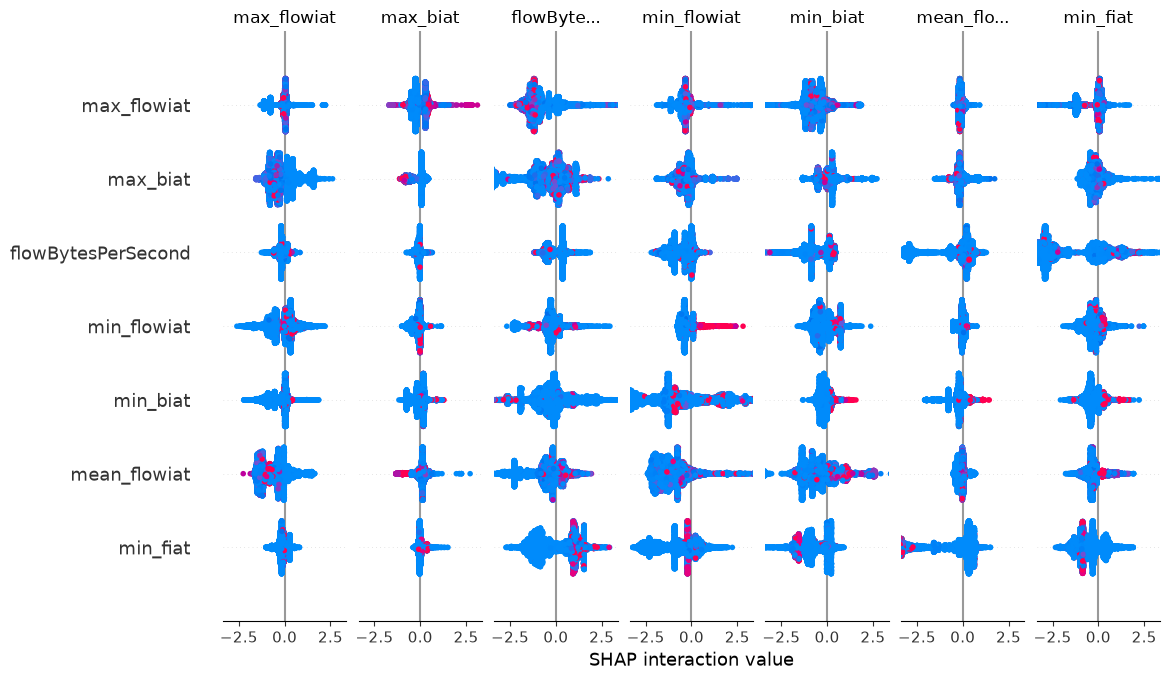

In [23]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

In [23]:
#Feature Importance

In [24]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
16         mean_active    0.076260
14         std_flowiat    0.066938
13        mean_flowiat    0.057651
8            mean_biat    0.057001
11         min_flowiat    0.054365
12         max_flowiat    0.053863
4             min_biat    0.053531
1           total_fiat    0.050856
0             duration    0.049101
6             max_biat    0.048781
2           total_biat    0.045091
9    flowPktsPerSecond    0.042120
22            std_idle    0.041593
5             max_fiat    0.037651
10  flowBytesPerSecond    0.036085
3             min_fiat    0.034508
7            mean_fiat    0.034167
21            max_idle    0.033964
17          max_active    0.033549
20           mean_idle    0.027462
19            min_idle    0.025649
18          std_active    0.021854
15          min_active    0.017959


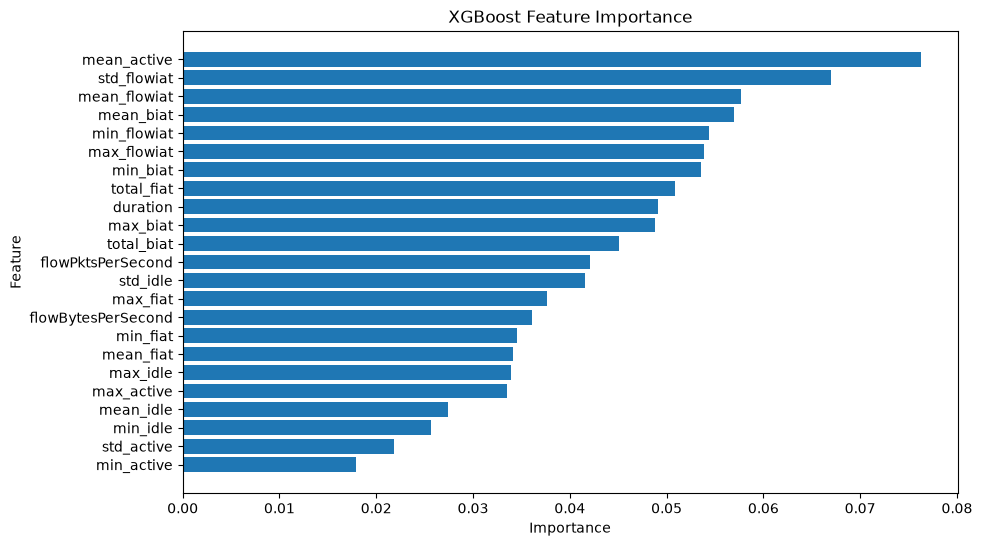

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [26]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

In [27]:
print(shap_values)

[[[ 8.13206136e-02  1.20511301e-01 -1.41740978e-01 ... -1.74148493e-02
   -1.09035276e-01  2.71242224e-02]
  [ 1.96070224e-01  3.58517952e-02 -1.55283421e-01 ...  9.84474048e-02
   -3.04363519e-01 -3.17542344e-01]
  [-4.88637239e-01 -3.65478098e-02 -3.75905573e-01 ...  3.83353308e-02
    1.84792362e-03 -9.50043276e-02]
  ...
  [-1.11700006e-01  1.09934341e-02  1.12022543e-02 ...  4.74055763e-03
   -8.67055282e-02  2.60501425e-03]
  [-5.76364174e-02 -1.35088656e-02  1.56409554e-02 ...  1.39829079e-02
   -1.99242644e-02  1.15192169e-02]
  [-3.12303789e-02 -2.55821079e-01 -1.25717759e-01 ... -1.46714936e-03
    8.76692822e-04 -7.41094910e-03]]

 [[-1.88336641e-01 -1.64294094e-01 -5.49002253e-02 ... -6.35197103e-01
    2.20058769e-01 -2.29858346e-02]
  [-1.43243283e-01 -1.61046222e-01  4.19439301e-02 ...  1.67780593e-02
    7.71226287e-02  1.02079675e-01]
  [-1.22263081e-01 -1.98405813e-02 -1.26538262e-01 ... -1.40849054e-01
    8.49138498e-01  5.93959242e-02]
  ...
  [-3.39049324e-02  2.8

In [28]:
print("TreeSHAP calculation completed successfully!")
print("SHAP values shape:", shap_values.shape)

TreeSHAP calculation completed successfully!
SHAP values shape: (11942, 23, 14)


In [29]:
print(feature_importance)

               Feature  Importance
16         mean_active    0.076260
14         std_flowiat    0.066938
13        mean_flowiat    0.057651
8            mean_biat    0.057001
11         min_flowiat    0.054365
12         max_flowiat    0.053863
4             min_biat    0.053531
1           total_fiat    0.050856
0             duration    0.049101
6             max_biat    0.048781
2           total_biat    0.045091
9    flowPktsPerSecond    0.042120
22            std_idle    0.041593
5             max_fiat    0.037651
10  flowBytesPerSecond    0.036085
3             min_fiat    0.034508
7            mean_fiat    0.034167
21            max_idle    0.033964
17          max_active    0.033549
20           mean_idle    0.027462
19            min_idle    0.025649
18          std_active    0.021854
15          min_active    0.017959


In [30]:
print(feature_importance.head(10))

         Feature  Importance
16   mean_active    0.076260
14   std_flowiat    0.066938
13  mean_flowiat    0.057651
8      mean_biat    0.057001
11   min_flowiat    0.054365
12   max_flowiat    0.053863
4       min_biat    0.053531
1     total_fiat    0.050856
0       duration    0.049101
6       max_biat    0.048781
